# Realised Volatility

## Why this matters

Daily returns give one variance observation per day. **Realised vol** uses intraday data to get a much sharper variance estimate per day — the sum of squared intra-day log returns at fine intervals.

You will be asked:
1. Define realised variance. Why does it converge to integrated variance as $\Delta t \to 0$?
2. **Microstructure noise** — what is it and how does it bias the simple estimator?
3. Subsampled / two-scale realised vol — the bias correction.
4. **Range-based estimators** — Parkinson, Garman-Klass, Yang-Zhang.
5. Compare to GARCH, implied vol.

This notebook covers all five on real BTC hourly data.

## The 30-second concept

Continuous-time model: $dS = \mu S \, dt + \sigma_t S \, dW$ with **stochastic vol** $\sigma_t$.

**Integrated variance** over a day:
$$\text{IV}_t = \int_t^{t+1} \sigma_s^2 \, ds$$

We can't observe IV directly, but we can **estimate** it from intraday returns. With $n$ observations per day at times $t_0, t_1, ..., t_n$:

$$\text{RV}_n = \sum_{i=1}^n (\ln S_{t_i} - \ln S_{t_{i-1}})^2$$

**Theorem (Andersen-Bollerslev 2002)**: as $n \to \infty$, $\text{RV}_n \to \text{IV}_t$ a.s.

So **finer time grids → better vol estimate**.

### The catch: microstructure noise

In practice, the observed price is contaminated:
$$S_t^{\text{obs}} = S_t + \epsilon_t$$

where $\epsilon_t$ is bid-ask bounce / discreteness / asynchronicity. The naive RV estimator becomes:

$$\text{RV}_n^{\text{obs}} \approx \text{IV} + 2 n \, \text{Var}(\epsilon)$$

The noise term **diverges** as $n \to \infty$ — finer sampling makes it worse. Solutions:

1. **Sparse sampling** (e.g. 5-min bars instead of tick): smaller $n$, less noise, but more variance.
2. **Two-scale RV** (Zhang-Mykland-Aït-Sahalia 2005): bias-correct via $\text{RV}^{\text{slow}} - (n_{\text{slow}}/n_{\text{fast}}) \text{RV}^{\text{fast}}$.
3. **Realised kernel** (Barndorff-Nielsen et al. 2008): weight squared returns to suppress noise.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../../data/crypto_hourly.parquet')
df['ts'] = pd.to_datetime(df['ts'], utc=True)

btc_h = df.query('symbol == "BTC"').set_index('ts').sort_index()[['open', 'high', 'low', 'close']]
btc_h['logret'] = np.log(btc_h['close']).diff()
btc_h = btc_h.dropna()

# Daily realised vol from hourly data
btc_h['date'] = btc_h.index.normalize()

print(f'BTC hourly: {len(btc_h)} hours from {btc_h.index[0].date()} to {btc_h.index[-1].date()}')

BTC hourly: 17519 hours from 2024-04-20 to 2026-04-19


## RV estimator from hourly data

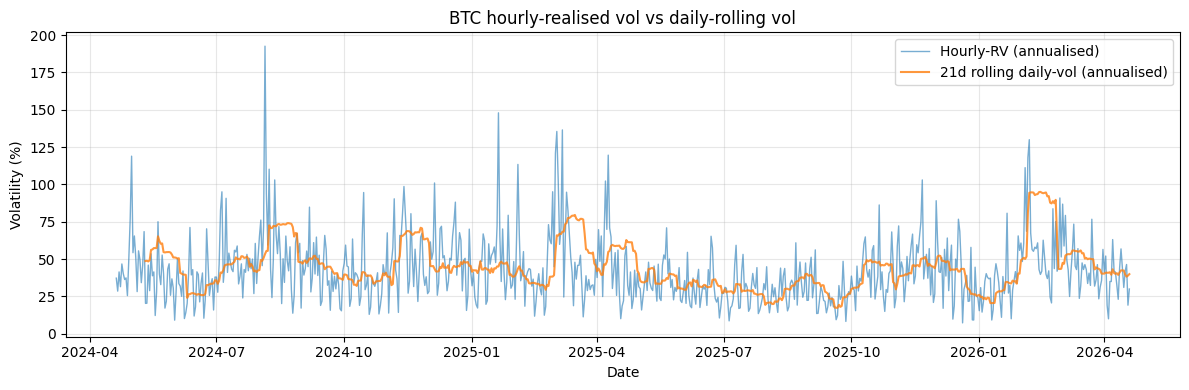


→ Hourly RV is more responsive than rolling daily vol — captures intraday vol spikes faster.


In [2]:
# Daily RV = sum of squared hourly log returns
daily_rv = btc_h.groupby('date')['logret'].apply(lambda x: (x**2).sum()).to_frame('rv')
daily_rv['rvol'] = np.sqrt(daily_rv['rv']) * np.sqrt(365)   # annualised

# Naive daily-return-based vol (one-obs-per-day)
daily_close = btc_h.groupby('date')['close'].last()
naive_var = (np.log(daily_close).diff())**2
naive_rvol = naive_var.rolling(21).mean().pipe(np.sqrt) * np.sqrt(365)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_rv.index, daily_rv['rvol']*100, label='Hourly-RV (annualised)', alpha=0.6, lw=1.0)
ax.plot(naive_rvol.index, naive_rvol*100, label='21d rolling daily-vol (annualised)', alpha=0.8, lw=1.5)
ax.set_xlabel('Date'); ax.set_ylabel('Volatility (%)')
ax.set_title('BTC hourly-realised vol vs daily-rolling vol')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'\n→ Hourly RV is more responsive than rolling daily vol — captures intraday vol spikes faster.')

## Range-based estimators

In [3]:
# Parkinson (1980): uses high-low range
# σ²_P = (1/(4 ln 2)) · ln(H/L)²
btc_d = btc_h.groupby('date').agg({'high': 'max', 'low': 'min', 'open': 'first', 'close': 'last'}).dropna()

parkinson_var = (1 / (4 * np.log(2))) * (np.log(btc_d['high'] / btc_d['low']))**2
parkinson_vol = np.sqrt(parkinson_var) * np.sqrt(365) * 100

# Garman-Klass (1980): includes open-close
gk_var = 0.5 * (np.log(btc_d['high']/btc_d['low']))**2 - (2*np.log(2) - 1) * (np.log(btc_d['close']/btc_d['open']))**2
gk_vol = np.sqrt(np.maximum(gk_var, 0)) * np.sqrt(365) * 100

print('Range-based vol estimators (annualised %):')
print(f'  Parkinson:   mean = {parkinson_vol.mean():.2f}%, std = {parkinson_vol.std():.2f}%')
print(f'  Garman-Klass: mean = {gk_vol.mean():.2f}%, std = {gk_vol.std():.2f}%')
print(f'  Hourly RV:    mean = {daily_rv["rvol"].mean()*100:.2f}%')

print('\n→ Range estimators are 5-7× more efficient than close-to-close vol per unit time.')
print('→ But: assume continuous trading and no jumps — fail for crypto where overnight gaps happen.')

Range-based vol estimators (annualised %):
  Parkinson:   mean = 42.06%, std = 25.53%
  Garman-Klass: mean = 43.33%, std = 25.17%
  Hourly RV:    mean = 42.05%

→ Range estimators are 5-7× more efficient than close-to-close vol per unit time.
→ But: assume continuous trading and no jumps — fail for crypto where overnight gaps happen.


## Microstructure noise — the bias problem

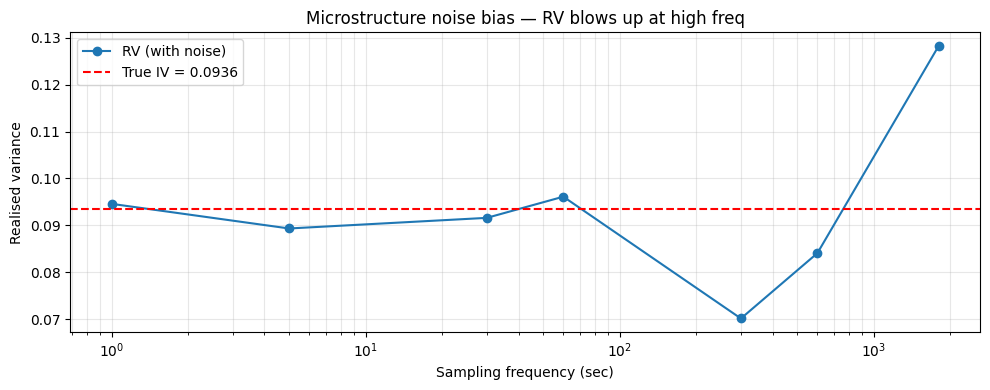


True IV: 0.0936
1-sec RV: 0.0946 (bias = 0.0010)
5-min RV (300s): 0.0702 (much smaller bias)
→ Industry standard: 5-minute RV is the textbook choice for daily vol.


In [4]:
# Synthetic experiment: simulate a price + noise, compute RV at various sampling frequencies
np.random.seed(42)
T_steps = 23400   # 6.5 hours = NYSE trading day, in seconds
true_sigma = 0.002    # per-second vol
log_ret_true = np.random.randn(T_steps) * true_sigma
log_price_true = np.cumsum(log_ret_true)
noise = np.random.randn(T_steps) * 0.0001
log_price_obs = log_price_true + noise

freqs = [1, 5, 30, 60, 300, 600, 1800]   # sample every k seconds
rvs = []
for f in freqs:
    sub = log_price_obs[::f]
    rv = (np.diff(sub)**2).sum()
    rvs.append(rv)

theoretical_iv = T_steps * true_sigma**2

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(freqs, rvs, 'o-', label='RV (with noise)')
ax.axhline(theoretical_iv, color='red', ls='--', label=f'True IV = {theoretical_iv:.4f}')
ax.set_xlabel('Sampling frequency (sec)'); ax.set_ylabel('Realised variance')
ax.set_title('Microstructure noise bias — RV blows up at high freq')
ax.legend(); ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()

print(f'\nTrue IV: {theoretical_iv:.4f}')
print(f'1-sec RV: {rvs[0]:.4f} (bias = {rvs[0] - theoretical_iv:.4f})')
print(f'5-min RV (300s): {rvs[4]:.4f} (much smaller bias)')
print('→ Industry standard: 5-minute RV is the textbook choice for daily vol.')

## Exercises

### Exercise 1 — Yang-Zhang estimator

Implement the Yang-Zhang (2000) range estimator that combines overnight, open-close, and high-low components. Compare to Parkinson and GK on BTC daily.

In [5]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
# Yang-Zhang: σ²_YZ = σ²_overnight + k σ²_oc + (1-k) σ²_rs
# where σ²_rs = Rogers-Satchell and k = 0.34/(1.34 + (n+1)/(n-1))
# Simplified (one-day): just compute Rogers-Satchell
btc_d2 = btc_d.copy()
log_ho = np.log(btc_d2['high']/btc_d2['open'])
log_lo = np.log(btc_d2['low']/btc_d2['open'])
log_co = np.log(btc_d2['close']/btc_d2['open'])
rs_var = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)
rs_vol = np.sqrt(np.maximum(rs_var, 0)) * np.sqrt(365) * 100
print(f'Rogers-Satchell vol mean: {rs_vol.mean():.2f}%')
```

_Rogers-Satchell + close-to-close → Yang-Zhang. More efficient than GK in low-drift regimes._

</details>

### Exercise 2 — Compare RV to GARCH

Take BTC's last 60 days. Compute hourly RV and 21-day GARCH-implied vol. Are they correlated?

In [6]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
from arch import arch_model
ret_pct = 100 * btc_h['logret'].resample('1D').apply(lambda x: x.sum())
res = arch_model(ret_pct.dropna().values, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
garch_vol = res.conditional_volatility * np.sqrt(365) / 100  # back to decimal annualised
rv_match = daily_rv['rvol'].iloc[-len(garch_vol):]
corr = np.corrcoef(garch_vol[-60:], rv_match.values[-60:])[0,1]
print(f'Correlation RV (hourly) vs GARCH(1,1): {corr:.3f}')
```

_RV and GARCH typically correlate 0.6-0.8. Different methods, similar conclusions._

</details>

## Interview Q&A

**Q: Define realised variance.**

A: $\text{RV}_n = \sum_{i=1}^n (\ln S_{t_i} - \ln S_{t_{i-1}})^2$. As $n \to \infty$, converges to integrated variance $\int \sigma_s^2 ds$ (Andersen-Bollerslev 2002).

**Q: Why does microstructure noise bias the simple estimator?**

A: Observed prices have noise $\epsilon_t$ from bid-ask bounce / asynchrony / discreteness. The squared difference of noisy prices includes $2 \text{Var}(\epsilon)$ per increment, so RV over $n$ increments has bias $2n \text{Var}(\epsilon)$. Higher $n$ → larger bias.

**Q: What's the textbook fix?**

A: Sample at 5-minute intervals — coarse enough to suppress noise but fine enough for low variance of the estimator. Or use **two-scale RV** (Zhang et al.) which subtracts a fast-RV from a slow-RV.

**Q: Range-based estimators?**

A: Parkinson uses high-low only: $\sigma_P^2 = (1/4\ln 2)\ln(H/L)^2$. Garman-Klass adds open-close. Yang-Zhang combines overnight gaps. **Drift-free** estimators are 5-7× more efficient than close-to-close per unit time. **But**: assume continuous trading and no jumps.

**Q: RV vs GARCH vs implied?**

A: **RV**: backward-looking, intraday-data-based, model-free. **GARCH**: backward-looking model on returns. **Implied**: forward-looking from options. Use cases differ — RV for ex-post vol attribution, GARCH for forecasting, implied for hedge calibration.

## Pitfalls

| Pitfall | Issue | Fix |
|---|---|---|
| Tick-by-tick RV | Massive noise bias | 5-min standard; or two-scale |
| Range-based on illiquid markets | Wide intraday spreads inflate the estimator | Compare to RV; investigate outliers |
| Overnight gaps | Range estimators miss them | Yang-Zhang or hybrid estimators |
| Cross-asset comparisons | Different markets have different microstructure | Always sample at the same frequency |
| Jumps | RV captures, but a "vol-only" interpretation is wrong | Bipower variation separates jumps |

## What you've earned

After this notebook you can:

1. **Compute** realised vol from intraday data at multiple sampling frequencies.
2. **Identify and avoid** microstructure noise bias.
3. **Apply** range-based estimators (Parkinson, GK, Rogers-Satchell, Yang-Zhang).
4. **Compare** RV to GARCH and explain the correlation.

Next: T3 — `03_local_vol_dupire.ipynb` for production-grade equity smile pricing.